project root setup

In [1]:
import os
import sys

PROJECT_ROOT = r"E:\Research\Multi-crop-plant-disease-detection"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root added to sys.path")
print(sys.path[0])

Project root added to sys.path
E:\Research\Multi-crop-plant-disease-detection


imports

In [2]:
import os
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk

from src.models import (
    build_mobilenetv2,
    build_resnet50,
    build_efficientnetv2s,
)
from src.data_loader import (
    create_label_mappings,
    create_dataloaders,
    HFDatasetWrapperGradCAM,
)
from src.transforms import (
    get_train_transform,
    get_val_test_transform,
)
from src.train import train_model
from src.evaluate import (
    evaluate_model,
    generate_classification_report_df,
    generate_confusion_matrix,
)
from src.gradcam import (
    GradCAM,
    denormalize_image,
    resize_cam,
    overlay_heatmap,
)
from src.utils import (
    set_seed,
    get_device,
    ensure_dirs,
)

print("All src imports OK")

All src imports OK


setup

In [3]:
SEED = 42
DATASET_PATH = "D:/plant_disease_data/bd_crop_dataset"
MODEL_SAVE_DIR = "E:/Research/Multi-crop-plant-disease-detection/models"
OUTPUT_DIR = "E:/Research/Multi-crop-plant-disease-detection/outputs"

set_seed(SEED)
device = get_device()

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ensure_dirs([
    MODEL_SAVE_DIR,
    OUTPUT_DIR,
    os.path.join(OUTPUT_DIR, "tables"),
    os.path.join(OUTPUT_DIR, "figures"),
    os.path.join(OUTPUT_DIR, "gradcam"),
])

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


optional CUDA cleanup

In [4]:
gc.collect()
torch.cuda.empty_cache()
print("CUDA cache cleared")

CUDA cache cleared


load local dataset

In [6]:
ds = load_from_disk(DATASET_PATH)
print(ds)

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 86467
    })
    valid: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 24698
    })
    test: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 12423
    })
})


class mappings

In [7]:
class_names, label2id, id2label = create_label_mappings(ds["train"])
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Number of classes: 94
First 10 classes: ['Banana_Black_Pitting_or_Banana_Rust', 'Banana_Crown_Rot', 'Banana_Healthy', 'Banana_fungal_disease', 'Banana_leaf_Banana_Scab_Moth', 'Banana_leaf_Black_Sigatoka', 'Banana_leaf_Healthy', 'Banana_leaf__Black_Leaf_Streak', 'Banana_leaf__Panama_Disease.', 'Cauliflower_Bacterial_spot_rot']


transforms

In [8]:
train_transform = get_train_transform(image_size=224)
val_test_transform = get_val_test_transform(image_size=224)

dataloaders

In [9]:
BATCH_SIZE = 32

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = create_dataloaders(
    ds=ds,
    label2id=label2id,
    train_transform=train_transform,
    val_test_transform=val_test_transform,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=True,
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2703
Valid batches: 772
Test batches: 389


one batch sanity check

In [10]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 5 labels:", labels[:5])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 5 labels: tensor([46, 20, 46, 48, 63])


choose model

In [ ]:
MODEL_NAME = "EfficientNetV2S"

if MODEL_NAME == "MobileNetV2":
    model = build_mobilenetv2(num_classes)
elif MODEL_NAME == "ResNet50":
    model = build_resnet50(num_classes)
elif MODEL_NAME == "EfficientNetV2S":
    model = build_efficientnetv2s(num_classes)
else:
    raise ValueError("Unsupported model name")

print(f"{MODEL_NAME} initialized")

optional training block

In [11]:
RUN_TRAINING = False
EPOCHS = 5
LR = 1e-4

if RUN_TRAINING:
    best_model_path, best_val_f1, history_df = train_model(
        model_name=MODEL_NAME,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        model_save_dir=MODEL_SAVE_DIR,
        epochs=EPOCHS,
        lr=LR,
    )

    print("Best model path:", best_model_path)
    print("Best validation F1:", best_val_f1)
    display(history_df.head())
else:
    print("Training skipped")

Training skipped


load existing trained checkpoint

In [14]:
MODEL_NAME = "EfficientNetV2S"

if MODEL_NAME == "MobileNetV2":
    model = build_mobilenetv2(num_classes)
elif MODEL_NAME == "ResNet50":
    model = build_resnet50(num_classes)
elif MODEL_NAME == "EfficientNetV2S":
    model = build_efficientnetv2s(num_classes)
else:
    raise ValueError("Unsupported model name")

print(f"{MODEL_NAME} initialized")

EfficientNetV2S initialized


In [15]:
if MODEL_NAME == "MobileNetV2":
    model = build_mobilenetv2(num_classes)
    best_model_path = os.path.join(MODEL_SAVE_DIR, "mobilenetv2_best.pth")
elif MODEL_NAME == "ResNet50":
    model = build_resnet50(num_classes)
    best_model_path = os.path.join(MODEL_SAVE_DIR, "resnet50_best.pth")
elif MODEL_NAME == "EfficientNetV2S":
    model = build_efficientnetv2s(num_classes)
    best_model_path = os.path.join(MODEL_SAVE_DIR, "efficientnetv2s_best.pth")

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)
model.eval()

print("Loaded checkpoint:", best_model_path)

Loaded checkpoint: E:/Research/Multi-crop-plant-disease-detection/models\efficientnetv2s_best.pth


evaluate model

In [16]:
test_acc, test_precision, test_recall, test_f1, all_labels, all_preds = evaluate_model(
    model,
    test_loader,
    device,
)

print("Test Accuracy :", test_acc)
print("Test Precision:", test_precision)
print("Test Recall   :", test_recall)
print("Test F1-score :", test_f1)

Test Accuracy : 0.9574981888432745
Test Precision: 0.9605701589045743
Test Recall   : 0.9574981888432745
Test F1-score : 0.9571011114810608


classification report

In [17]:
report_df = generate_classification_report_df(all_labels, all_preds, class_names)
report_df.head()

,precision,recall,f1-score,support
Banana_Black_Pitting_or_Banana_Rust,0.790262,0.531486,0.635542,397.0
Banana_Crown_Rot,0.647059,0.379310,0.478261,29.0
Banana_Healthy,0.684211,0.722222,0.702703,18.0
Banana_fungal_disease,0.574822,0.855124,0.687500,283.0
Banana_leaf_Banana_Scab_Moth,0.909091,1.000000,0.952381,10.0


summary metrics

In [18]:
summary_df = report_df.loc[["accuracy", "macro avg", "weighted avg"]]
summary_df

,precision,recall,f1-score,support
accuracy,0.957498,0.957498,0.957498,0.957498
macro avg,0.933704,0.926584,0.925152,12423.000000
weighted avg,0.960570,0.957498,0.957101,12423.000000


save classification report

In [19]:
report_path = os.path.join(OUTPUT_DIR, "tables", f"{MODEL_NAME.lower()}_classification_report_clean.csv")
summary_path = os.path.join(OUTPUT_DIR, "tables", f"{MODEL_NAME.lower()}_summary_metrics_clean.csv")

report_df.to_csv(report_path)
summary_df.to_csv(summary_path)

print("Saved report to:", report_path)
print("Saved summary to:", summary_path)

Saved report to: E:/Research/Multi-crop-plant-disease-detection/outputs\tables\efficientnetv2s_classification_report_clean.csv
Saved summary to: E:/Research/Multi-crop-plant-disease-detection/outputs\tables\efficientnetv2s_summary_metrics_clean.csv


confusion matrix

In [20]:
cm = generate_confusion_matrix(all_labels, all_preds)
print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (94, 94)


plot confusion matrix

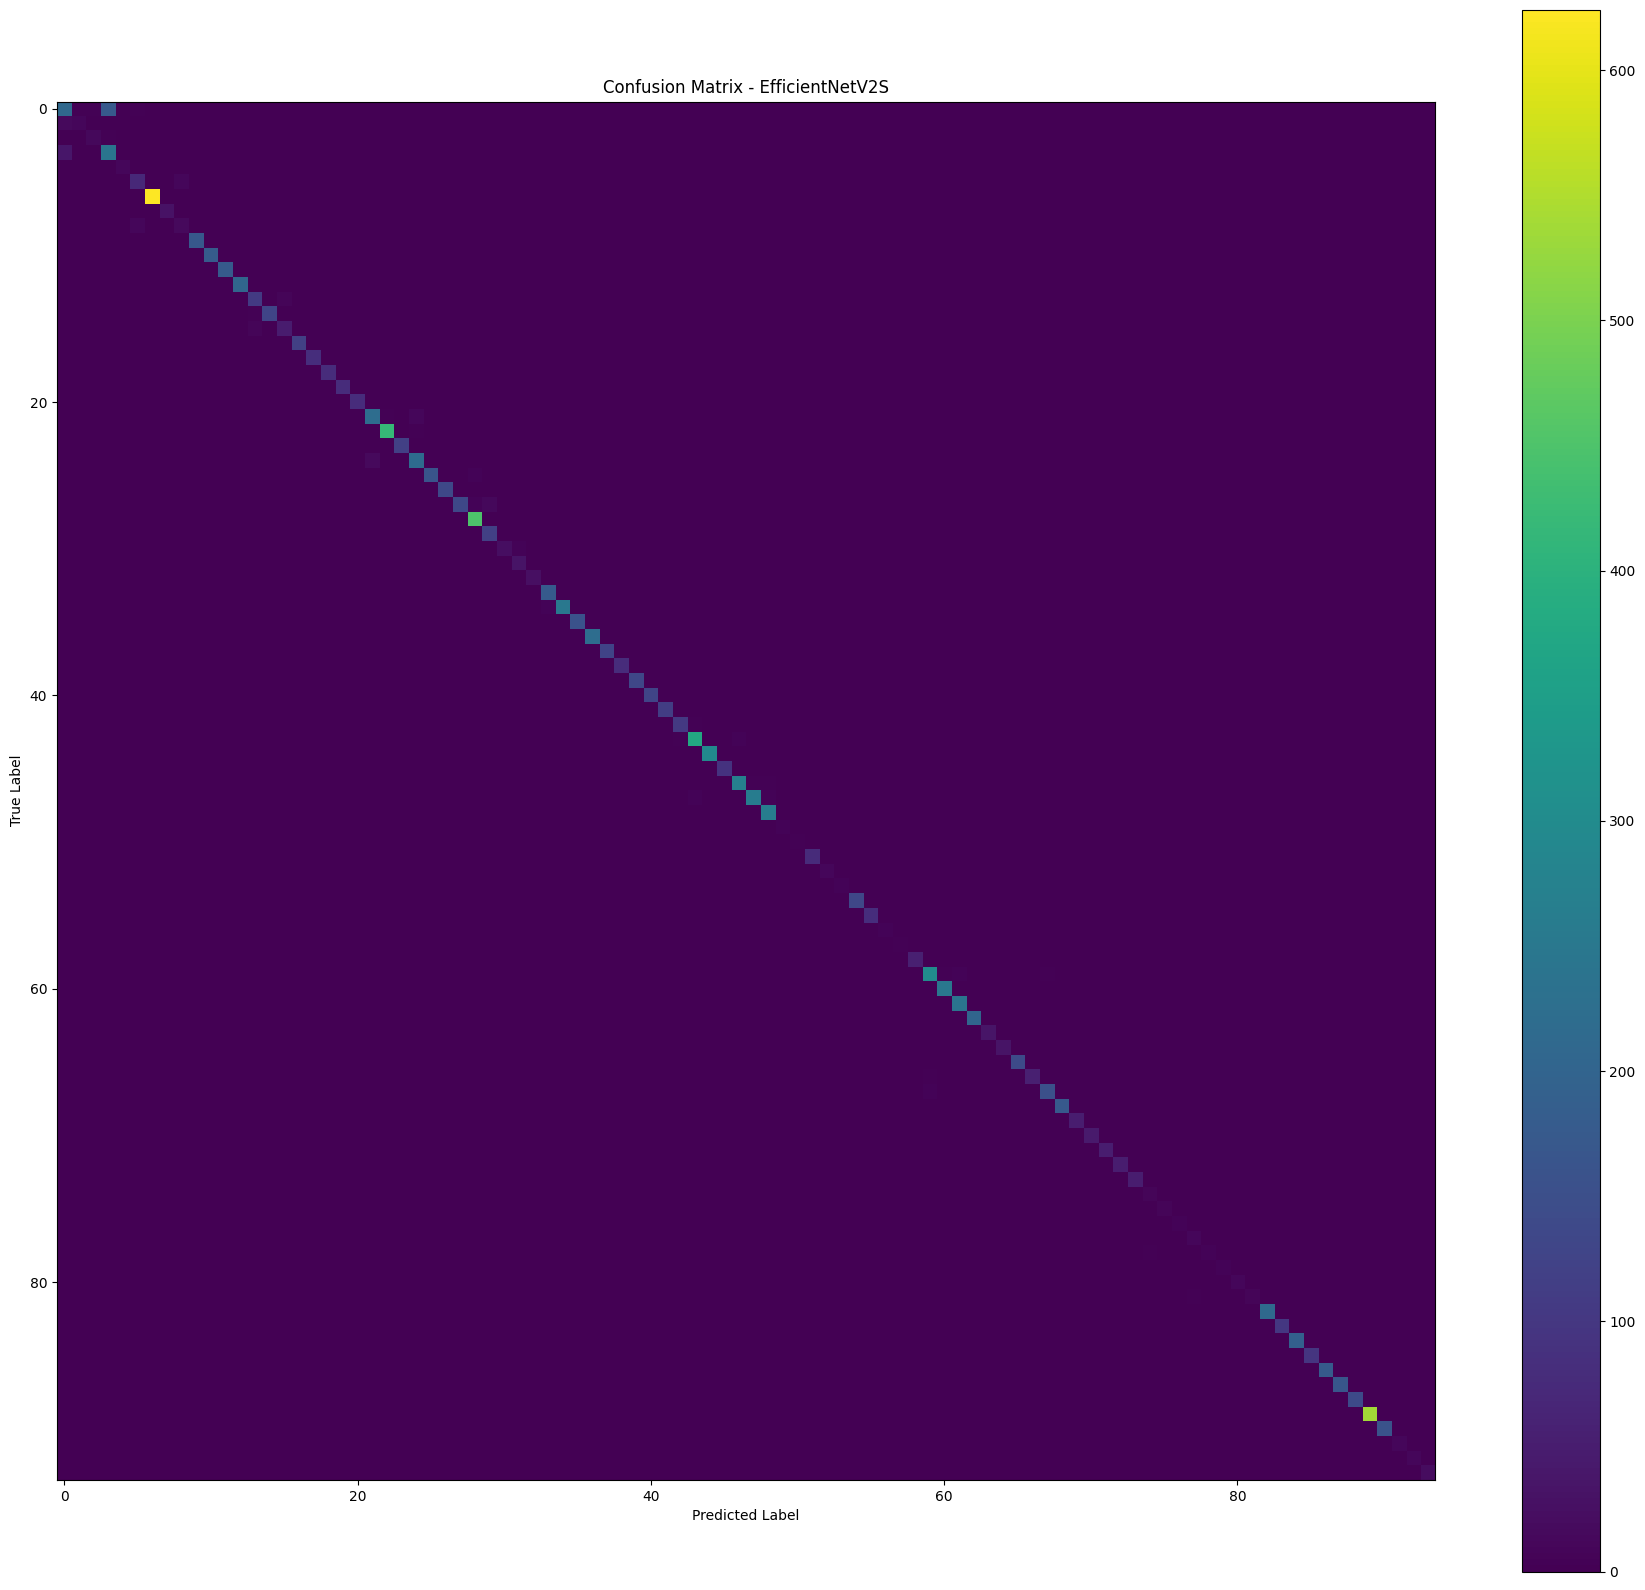

In [21]:
plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix - {MODEL_NAME}")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

save confusion matrix figure

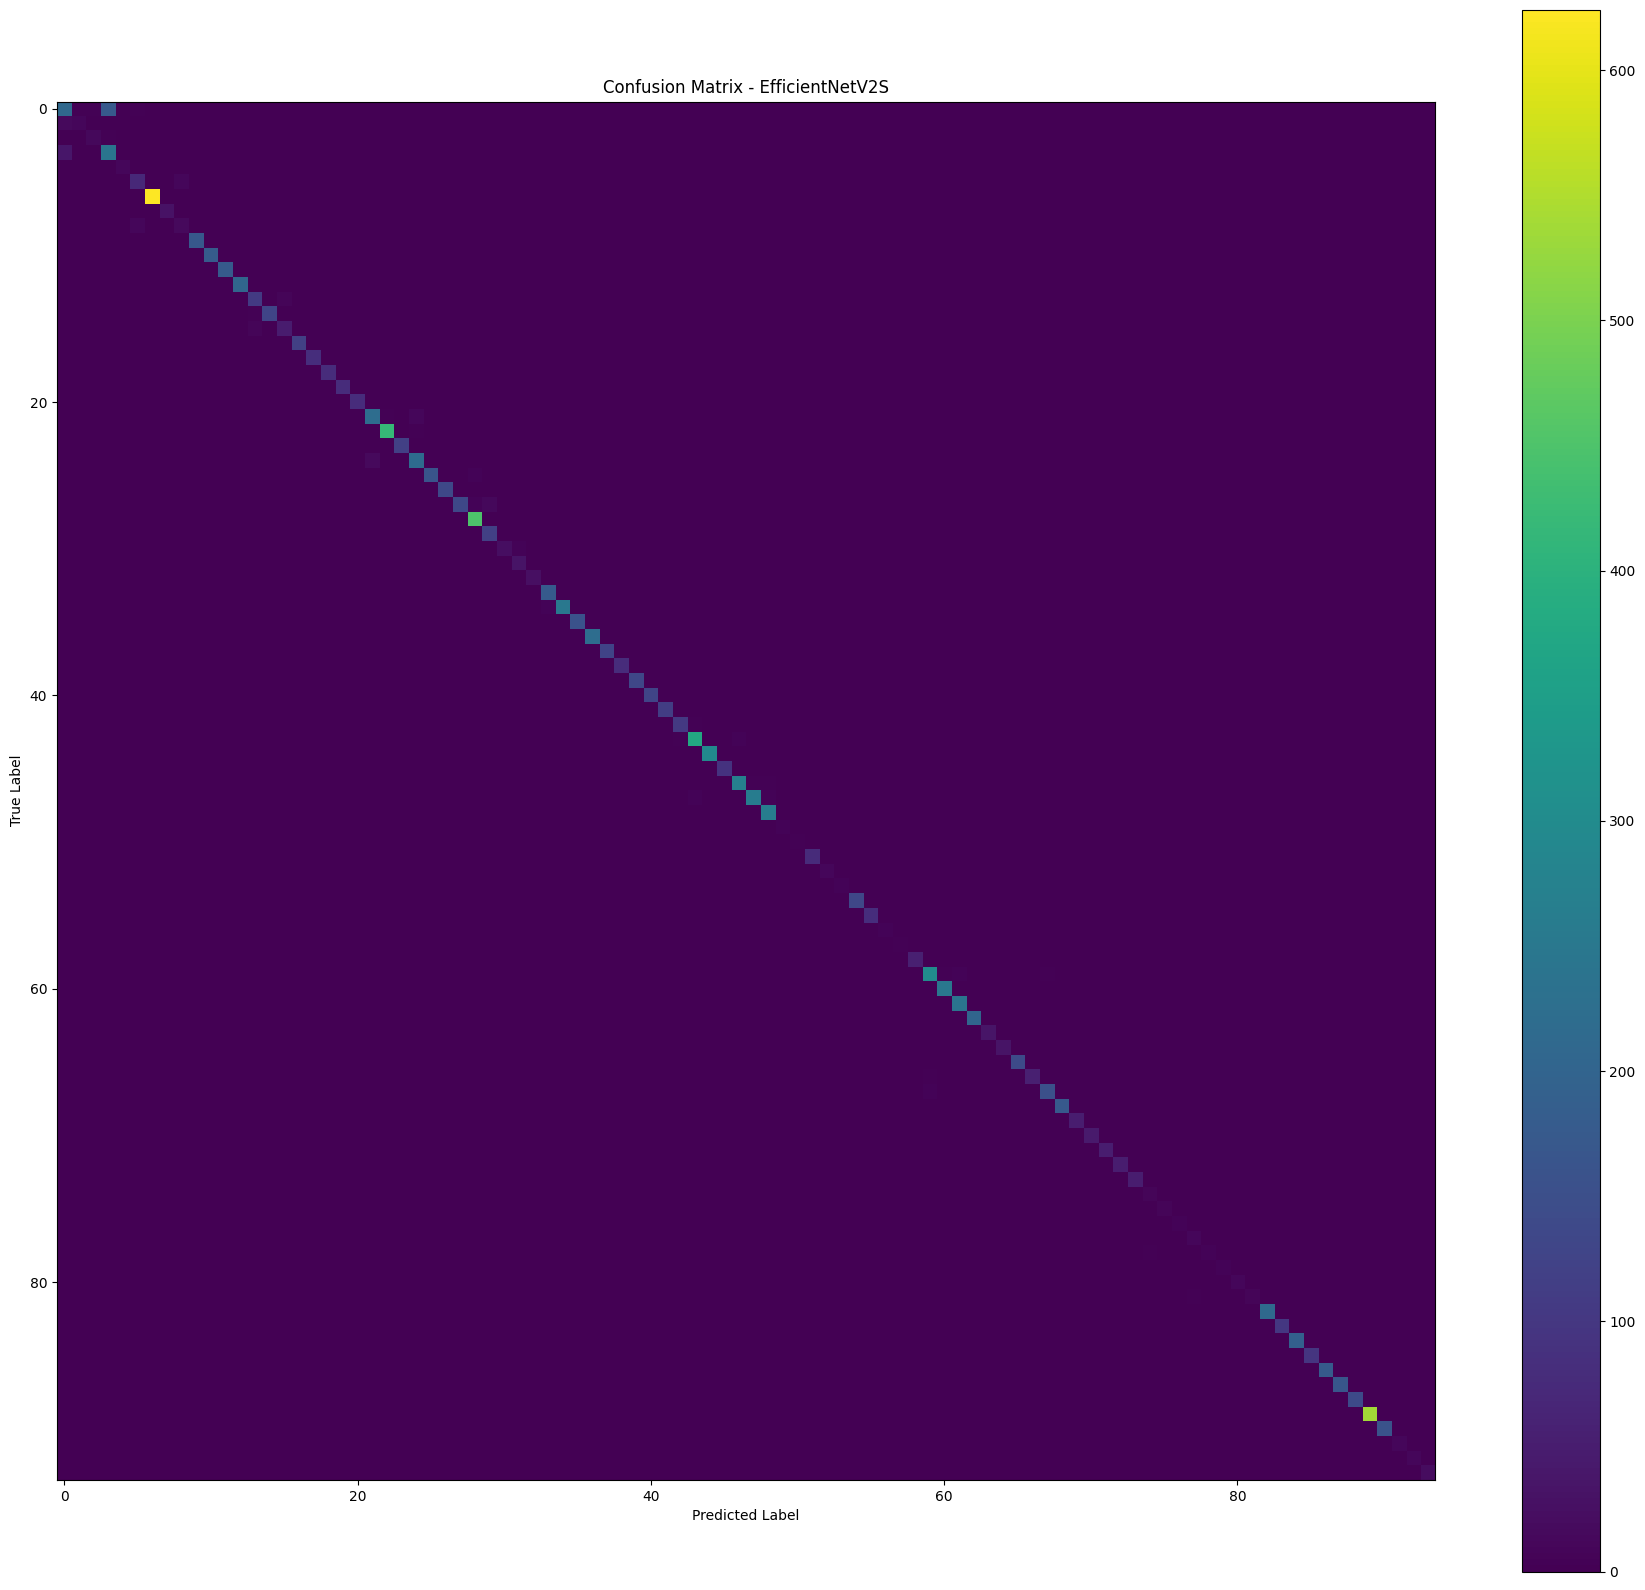

Saved confusion matrix figure to: E:/Research/Multi-crop-plant-disease-detection/outputs\figures\efficientnetv2s_confusion_matrix_clean.png


In [22]:
cm_fig_path = os.path.join(OUTPUT_DIR, "figures", f"{MODEL_NAME.lower()}_confusion_matrix_clean.png")

plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix - {MODEL_NAME}")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure to:", cm_fig_path)

lowest-performing classes

In [23]:
per_class_df = report_df.iloc[:-3].copy()
low_f1_df = per_class_df.sort_values(by="f1-score", ascending=True).head(10)
low_f1_df[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
Banana_Crown_Rot,0.647059,0.379310,0.478261,29.0
Potato_Blackleg,0.400000,0.666667,0.500000,6.0
Banana_leaf__Panama_Disease.,0.586207,0.607143,0.596491,28.0
Potato_Pink_Rot,1.000000,0.428571,0.600000,7.0
Potato_Miscellaneous,0.714286,0.555556,0.625000,9.0
Banana_Black_Pitting_or_Banana_Rust,0.790262,0.531486,0.635542,397.0
Banana_fungal_disease,0.574822,0.855124,0.687500,283.0
Banana_Healthy,0.684211,0.722222,0.702703,18.0
Potato_Common_Scab,0.625000,0.833333,0.714286,6.0
Tea_Anthracnose,0.571429,1.000000,0.727273,8.0


Grad-CAM dataset

In [24]:
gradcam_dataset = HFDatasetWrapperGradCAM(
    ds["test"],
    label2id=label2id,
    transform=val_test_transform,
)

print("Grad-CAM dataset ready:", len(gradcam_dataset))

Grad-CAM dataset ready: 12423


target layer for EfficientNetV2S

In [25]:
if MODEL_NAME == "EfficientNetV2S":
    target_layer = model.features[-1]
elif MODEL_NAME == "ResNet50":
    target_layer = model.layer4
elif MODEL_NAME == "MobileNetV2":
    target_layer = model.features[-1]
else:
    raise ValueError("Unsupported model name for Grad-CAM")

print(target_layer)

Conv2dNormActivation(
  (0): Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


initialize Grad-CAM

In [26]:
gradcam = GradCAM(model, target_layer)
print("Grad-CAM initialized")

Grad-CAM initialized


one sample Grad-CAM demo

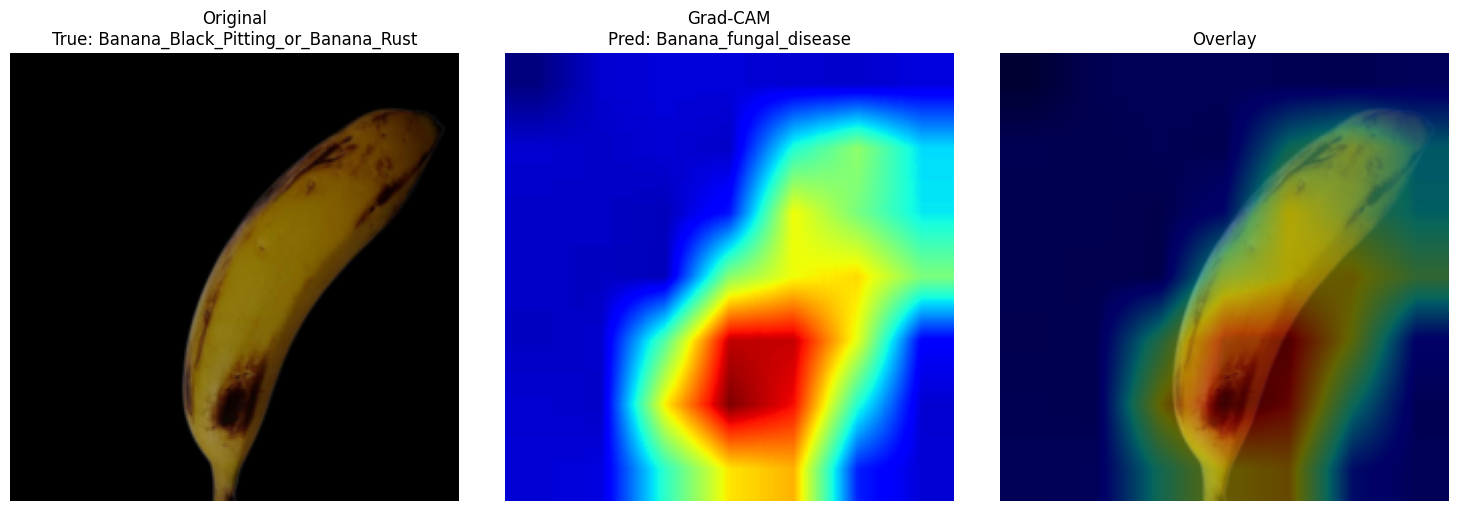

In [27]:
sample_idx = 0

image_tensor, true_label, original_image, true_label_name = gradcam_dataset[sample_idx]
input_tensor = image_tensor.unsqueeze(0).to(device)

cam, pred_idx = gradcam.generate(input_tensor)
pred_label_name = id2label[pred_idx]

img_np = denormalize_image(image_tensor)
cam_resized = resize_cam(cam, size=(224, 224))
overlay = overlay_heatmap(img_np, cam_resized)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original\nTrue: {true_label_name}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title(f"Grad-CAM\nPred: {pred_label_name}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

save one Grad-CAM demo image

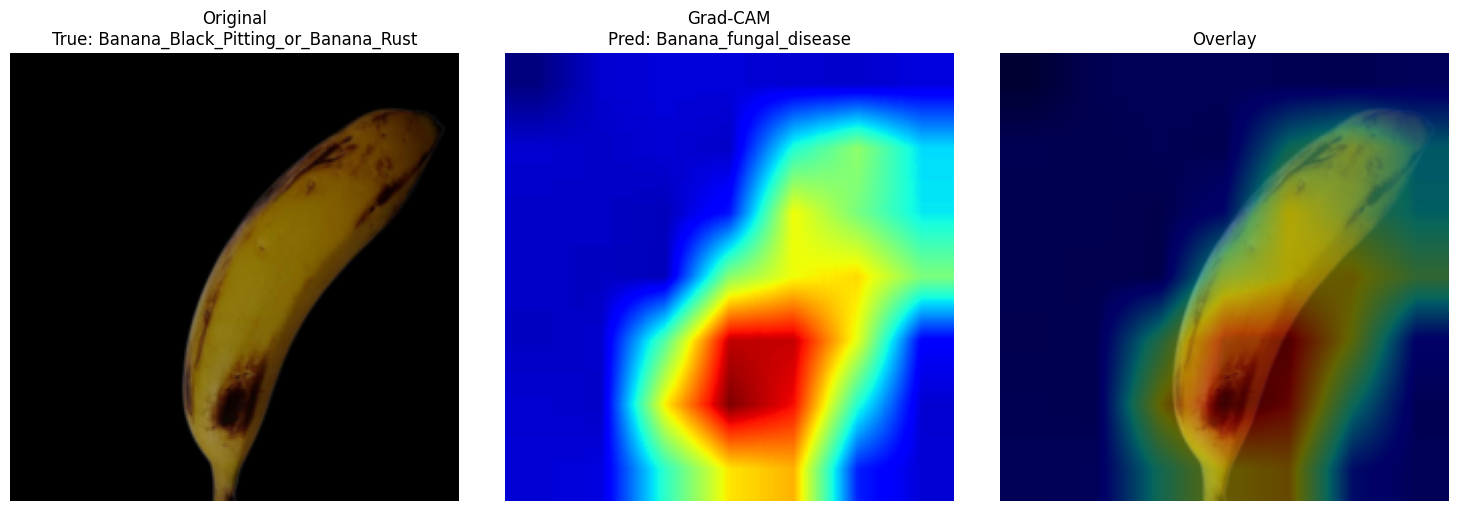

Saved Grad-CAM demo to: E:/Research/Multi-crop-plant-disease-detection/outputs\gradcam\efficientnetv2s_gradcam_demo.png


In [28]:
gradcam_demo_path = os.path.join(OUTPUT_DIR, "gradcam", f"{MODEL_NAME.lower()}_gradcam_demo.png")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original\nTrue: {true_label_name}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title(f"Grad-CAM\nPred: {pred_label_name}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig(gradcam_demo_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Grad-CAM demo to:", gradcam_demo_path)

cleanup hooks

In [29]:
gradcam.remove_hooks()
print("Grad-CAM hooks removed")

Grad-CAM hooks removed
